# Visualize Denoising Metric Comparisons

This notebook collects metric outputs from `results_smooth`, `results_magic`, and `results_log_norm`, then compares them side by side.

It is designed to work directly from the folder structure in `testing_different_denoisings` and should keep working if you add more samples later.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')


In [13]:
BASE_DIR = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings')

RESULT_DIRS = {
    'smooth': BASE_DIR / 'results_smooth',
    'magic': BASE_DIR / 'results_magic',
    'log_norm': BASE_DIR / 'results_log_norm',
}

sample_key = '1105BL'
method_order = ['smooth', 'magic', 'log_norm']

BASE_DIR

PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/testing_different_denoisings')

In [14]:
def sample_prefix(path: Path) -> str:
    return path.name.split('__', 1)[0]


def load_result_tables(base_dir: Path, result_dirs: dict[str, Path]) -> tuple[pd.DataFrame, dict[str, dict[str, dict[str, Path]]]]:
    file_registry: dict[str, dict[str, dict[str, Path]]] = {}
    metrics_frames = []

    for method, folder in result_dirs.items():
        method_files: dict[str, dict[str, Path]] = {}
        for csv_path in sorted(folder.glob('*.csv')):
            prefix = sample_prefix(csv_path)
            suffix = csv_path.name.split('__', 1)[1]
            method_files.setdefault(prefix, {})[suffix] = csv_path

            if suffix == 'metrics_summary.csv':
                df = pd.read_csv(csv_path)
                df['method'] = method
                df['sample_key'] = prefix
                df['source_file'] = str(csv_path)
                metrics_frames.append(df)

        file_registry[method] = method_files

    metrics_df = pd.concat(metrics_frames, ignore_index=True)
    metrics_df['method'] = pd.Categorical(metrics_df['method'], categories=method_order, ordered=True)
    metrics_df = metrics_df.sort_values(['sample_key', 'method']).reset_index(drop=True)
    return metrics_df, file_registry


metrics_df, file_registry = load_result_tables(BASE_DIR, RESULT_DIRS)

available_samples = sorted(metrics_df['sample_key'].unique())
print('Available sample keys:', available_samples)

if sample_key not in available_samples:
    raise ValueError(f'sample_key={sample_key!r} not found. Choose one of: {available_samples}')

sample_metrics = metrics_df.loc[metrics_df['sample_key'] == sample_key].copy()
display(sample_metrics)

Available sample keys: ['1105BL']


,sample_name,wes_sample_id,mode,bin_size_bp,min_genes_per_bin,insitu_file,n_rows,wes_threshold,insitu_threshold,auc_gain,auc_loss,auc_mean,precision_gain,precision_loss,precision_mean,recall_gain,recall_loss,recall_mean,f1_gain,f1_loss,f1_mean,method,sample_key,source_file
0,1105_BL,UE-2971-1105-0,binned,20000000,5,1105_BL_tumor_mean_smooth.csv,146,0.1036,0.0400,0.9500,0.9960,0.9730,0.6250,0.9565,0.7908,0.8333,0.8800,0.8567,0.7143,0.9167,0.8155,smooth,1105BL,/home/augusta/storage3/augusta/insituCNV/InSit...
1,1105_BL,UE-2971-1105-0,binned,20000000,5,1105_BL_tumor_mean_magic.csv,146,0.1036,0.0330,0.9762,0.9782,0.9772,0.5000,0.7586,0.6293,1.0000,0.8800,0.9400,0.6667,0.8148,0.7407,magic,1105BL,/home/augusta/storage3/augusta/insituCNV/InSit...
2,1105_BL,UE-2971-1105-0,binned,20000000,5,1105_BL_tumor_mean_log_norm.csv,146,0.1036,0.0238,0.9750,0.9729,0.9739,0.2857,0.7500,0.5179,1.0000,0.7200,0.8600,0.4444,0.7347,0.5896,log_norm,1105BL,/home/augusta/storage3/augusta/insituCNV/InSit...


## Summary Comparison

The table below reshapes the metrics summary into a tidy format for plotting.

In [15]:
metric_columns = [
    'auc_gain', 'auc_loss', 'auc_mean',
    'precision_gain', 'precision_loss', 'precision_mean',
    'recall_gain', 'recall_loss', 'recall_mean',
    'f1_gain', 'f1_loss', 'f1_mean',
]

tidy_metrics = sample_metrics.melt(
    id_vars=['sample_key', 'sample_name', 'method', 'wes_threshold', 'insitu_threshold'],
    value_vars=metric_columns,
    var_name='metric',
    value_name='value',
)
tidy_metrics[['metric_family', 'state']] = tidy_metrics['metric'].str.split('_', n=1, expand=True)

display(tidy_metrics.head())

,sample_key,sample_name,method,wes_threshold,insitu_threshold,metric,value,metric_family,state
0,1105BL,1105_BL,smooth,0.1036,0.0400,auc_gain,0.9500,auc,gain
1,1105BL,1105_BL,magic,0.1036,0.0330,auc_gain,0.9762,auc,gain
2,1105BL,1105_BL,log_norm,0.1036,0.0238,auc_gain,0.9750,auc,gain
3,1105BL,1105_BL,smooth,0.1036,0.0400,auc_loss,0.9960,auc,loss
4,1105BL,1105_BL,magic,0.1036,0.0330,auc_loss,0.9782,auc,loss


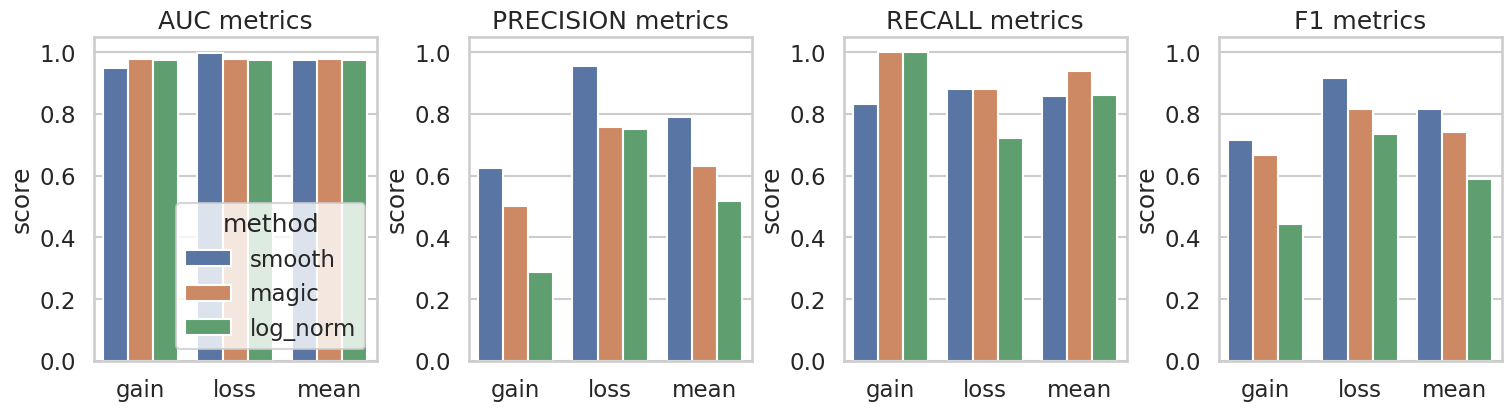

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)

family_order = ['auc', 'precision', 'recall', 'f1']
state_order = ['gain', 'loss', 'mean']

for ax, family in zip(axes, family_order):
    plot_df = tidy_metrics.loc[tidy_metrics['metric_family'] == family].copy()
    
    sns.barplot(
        data=plot_df,
        x='state',
        y='value',
        hue='method',
        order=state_order,
        hue_order=method_order,
        ax=ax,
    )
    
    ax.set_title(f'{family.upper()} metrics')
    ax.set_xlabel('')
    ax.set_ylabel('score')
    ax.set_ylim(0, 1.05)
    
    if ax is not axes[0]:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

# Add legend only once
axes[0].legend(title='method', loc='lower right')

plt.savefig("cnv_metrics_comparison.pdf", bbox_inches="tight")
plt.show()

In [17]:
selected_thresholds = sample_metrics[
    ['method', 'wes_threshold', 'insitu_threshold', 'auc_mean', 'f1_mean', 'precision_mean', 'recall_mean']
].set_index('method')
display(selected_thresholds)

,wes_threshold,insitu_threshold,auc_mean,f1_mean,precision_mean,recall_mean
method,,,,,,
smooth,0.1036,0.0400,0.9730,0.8155,0.7908,0.8567
magic,0.1036,0.0330,0.9772,0.7407,0.6293,0.9400
log_norm,0.1036,0.0238,0.9739,0.5896,0.5179,0.8600


## Threshold Grid Curves

These plots show how each denoising method behaves across the stored threshold grids and highlight the selected threshold from `metrics_summary.csv`.

In [18]:
def load_grid(method: str, suffix: str) -> pd.DataFrame:
    path = file_registry[method][sample_key][suffix]
    return pd.read_csv(path)


insitu_grids = []
wes_grids = []

for method in method_order:
    insitu_df = load_grid(method, 'insitu_threshold_f1_grid.csv')
    insitu_df['method'] = method
    insitu_grids.append(insitu_df)

    wes_df = load_grid(method, 'wes_threshold_auc_grid.csv')
    wes_df['method'] = method
    wes_grids.append(wes_df)

insitu_grid_df = pd.concat(insitu_grids, ignore_index=True)
wes_grid_df = pd.concat(wes_grids, ignore_index=True)

display(insitu_grid_df.head())
display(wes_grid_df.head())

,insitu_threshold,f1_gain,f1_loss,f1_mean,accuracy_3class,method
0,0.0400,0.7143,0.9167,0.8155,0.9452,smooth
1,0.0559,0.7273,0.8889,0.8081,0.9452,smooth
2,0.0292,0.6667,0.9388,0.8027,0.9452,smooth
3,0.0580,0.7273,0.8636,0.7955,0.9384,smooth
4,0.0292,0.6250,0.9600,0.7925,0.9452,smooth


,wes_threshold,auc_gain,auc_loss,auc_mean,n_truth_gain,n_truth_loss,method
0,0.1036,0.9500,0.9960,0.9730,6,25,smooth
1,0.1081,0.9500,0.9960,0.9730,6,25,smooth
2,0.1092,0.9500,0.9894,0.9697,6,24,smooth
3,0.0980,0.9332,0.9939,0.9636,7,26,smooth
4,0.1149,0.9500,0.9726,0.9613,6,20,smooth


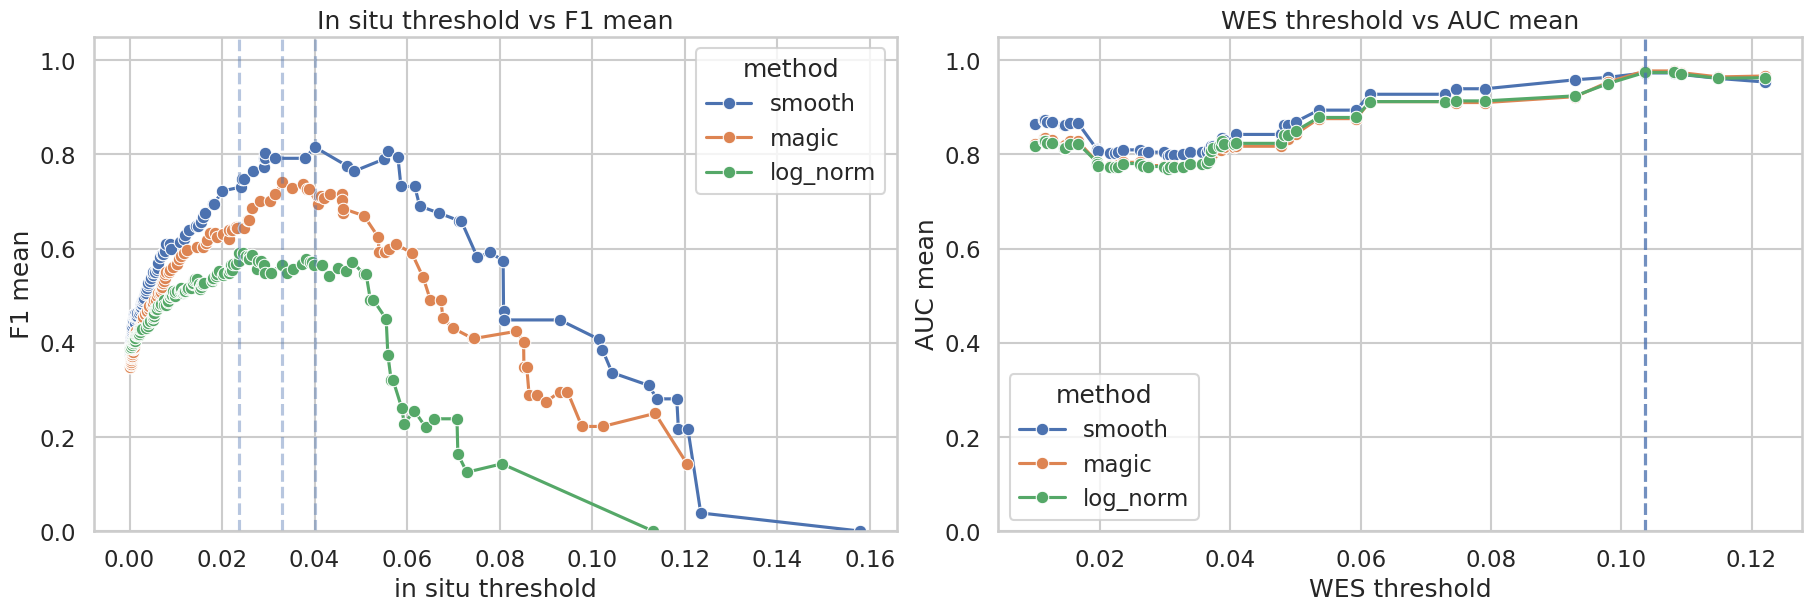

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.lineplot(
    data=insitu_grid_df,
    x='insitu_threshold',
    y='f1_mean',
    hue='method',
    hue_order=method_order,
    marker='o',
    ax=axes[0],
)
for method in method_order:
    row = selected_thresholds.loc[method]
    axes[0].axvline(row['insitu_threshold'], linestyle='--', alpha=0.4)
axes[0].set_title('In situ threshold vs F1 mean')
axes[0].set_ylabel('F1 mean')
axes[0].set_xlabel('in situ threshold')
axes[0].set_ylim(0, 1.05)

sns.lineplot(
    data=wes_grid_df,
    x='wes_threshold',
    y='auc_mean',
    hue='method',
    hue_order=method_order,
    marker='o',
    ax=axes[1],
)
for method in method_order:
    row = selected_thresholds.loc[method]
    axes[1].axvline(row['wes_threshold'], linestyle='--', alpha=0.4)
axes[1].set_title('WES threshold vs AUC mean')
axes[1].set_ylabel('AUC mean')
axes[1].set_xlabel('WES threshold')
axes[1].set_ylim(0, 1.05)

plt.savefig("cnv_metrics_comparison_across_thesholds.pdf", bbox_inches="tight")

plt.show()

## Confusion Matrices

Counts and row-normalized percentages are shown for each method to make class-specific behavior easier to compare.

In [20]:
def load_confusion(method: str, suffix: str) -> pd.DataFrame:
    path = file_registry[method][sample_key][suffix]
    df = pd.read_csv(path)
    df = df.rename(columns={df.columns[0]: 'truth'})
    return df.set_index('truth')


count_matrices = {method: load_confusion(method, 'confusion_matrix_counts.csv') for method in method_order}
pct_matrices = {method: load_confusion(method, 'confusion_matrix_row_pct.csv') for method in method_order}

count_matrices['smooth']

,loss,neutral,gain
truth,,,
gain,0,3,5
neutral,3,111,1
loss,22,1,0


## Optional: Inspect Per-bin Comparison Rows

Use this section if you want to compare the bin-level `wes_segmean` and `insitu_value` tables exported for each method.

In [21]:
comparison_frames = []

for method in method_order:
    path = file_registry[method][sample_key]['comparison_rows.csv']
    df = pd.read_csv(path)
    df['method'] = method
    comparison_frames.append(df)

comparison_df = pd.concat(comparison_frames, ignore_index=True)
display(comparison_df.head())

,mode,chr_num,start,end,x,wes_segmean,insitu_value,n_genes,truth,pred,method
0,binned,1,1,20000000,10000000.5000,0.0367,0.0011,63,0,0,smooth
1,binned,1,20000001,40000000,30000000.5000,0.0195,0.0090,82,0,0,smooth
2,binned,1,40000001,60000000,50000000.5000,0.0195,0.0559,45,0,1,smooth
3,binned,1,60000001,80000000,70000000.5000,0.0195,0.0033,21,0,0,smooth
4,binned,1,80000001,100000000,90000000.5000,0.0195,0.0005,21,0,0,smooth


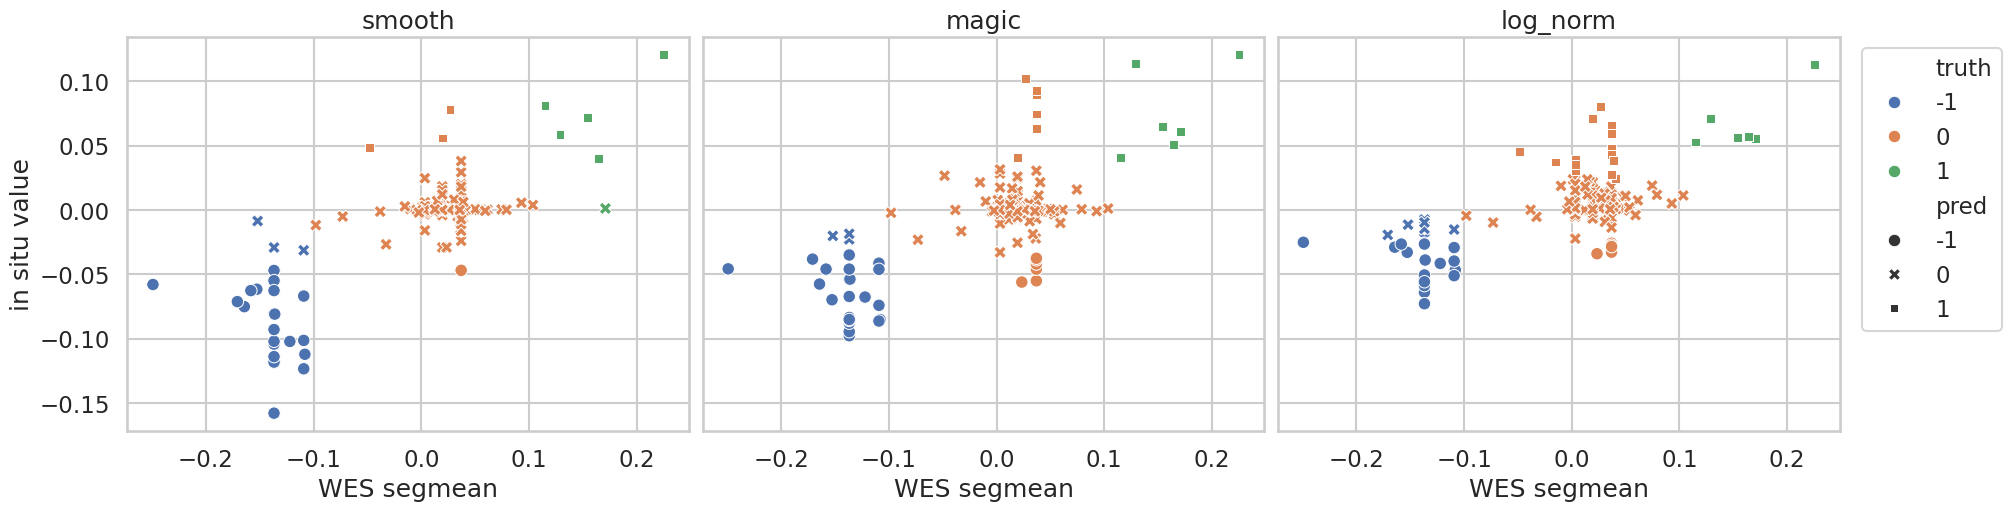

In [22]:
fig, axes = plt.subplots(1, len(method_order), figsize=(20, 5), sharex=True, sharey=True, constrained_layout=True)

for ax, method in zip(axes, method_order):
    plot_df = comparison_df.loc[comparison_df['method'] == method]
    sns.scatterplot(data=plot_df, x='wes_segmean', y='insitu_value', hue='truth', style='pred', palette='deep', ax=ax)
    ax.set_title(method)
    ax.set_xlabel('WES segmean')
    ax.set_ylabel('in situ value')

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes[:-1]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
axes[-1].legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()